# PROC OPTMODEL によるジョブショップのメイクスパン最小化

## エグゼクティブサマリー

小規模な離散生産セルでは、4 つの部品 — **ブラケット**、**フランジ**、**ハウジング**、**シャフト** — を、それぞれ 3 つの機械加工工程からなる固定シーケンスで通過させる必要があり、単一能力の 4 台の機械（**鋸盤**、**フライス盤**、**ドリル**、**研削盤**）を共有します。どの機械も同時に 2 つの工程を実行できず、各部品の工程はその技術的順序に従わなければなりません。このメイクスパン最小化スケジュールを **PROC OPTMODEL** の混合整数計画として定式化します — 開始時刻変数、終了-開始間の先行制約、そして機械を共有するすべての工程ペア間の選言的（big-*M*）非重複制約 — そしてこれを証明済みの最適解まで解きます。

MILP ソルバーは **最適メイクスパン 120 分**（`Solution Status = Optimal`、`Objective Value = 120`）を返します。得られたスケジュールは 12 の工程すべてを、各機械が同時に高々 1 つの部品しか処理せず、かつ各部品がその要求順序で 研削盤 の前に 鋸盤/フライス盤/ドリル を通るように配置します。2 つの工程がちょうど 120 分で終了します — ブラケット の研削と ハウジング のフライス加工 — したがって 研削盤 と フライス盤 の両機械が、スケジュール長を決定づけるクリティカルパス上にあります。

## データソース

すべてのデータはノートブック内で定義されています — 外部ファイルやネットワークは使用しません。

| データセット | 行数 | 主な変数 | 説明 |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | 工程 1 つにつき 1 行（4 部品 × 3 工程）。`machine`（1–4）は工程が必要とする機械、`dur` は分単位の処理時間、`jobname`/`mname` は読みやすい部品・機械のラベルです。 |
| `sched` | 12 | `op`, `start`, `finish` | OPTMODEL の出力：各工程の最適な開始分と終了分。 |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` に解いた時刻をマージし、機械順・開始順にソートしたもの — 人間が読めるスケジュールです。 |
| `mk` | 1 | `makespan` | 実現されたメイクスパン（最も遅い終了時刻）。 |

## スケジューリング問題

**ジョブショップ**では、複数の部品（「ジョブ」）がそれぞれ固定された工程シーケンスを通過し、各工程は特定の機械で実行されます。2 つの工程が同時に同じ機械を占有することはできず（機械は *単一* 資源です）、部品内では工程が技術的順序を守らなければなりません。計画者は、両方の規則を守りつつ、スケジュール全体の長さ — **メイクスパン** — をできるだけ小さく保つような、すべての工程の開始時刻を求めます。

これは古典的な選言的スケジューリング問題です。これを混合整数計画としてモデル化します：

- 各工程に対する連続だが整数の **開始時刻** `s[o]` と、メイクスパン変数 `Cmax`；
- **先行関係**：部品の工程 *k+1* は、工程 *k* が終了するより早くは開始しない；
- **選言的機械能力**：機械を共有する工程の各ペアについて、どちらが先かをバイナリ `y` が決定し、big-*M* 項が非アクティブな順序を無効化する — したがって 2 つの工程は決して重複しない；
- **目的**：`Cmax` を最小化する。これはすべての工程の終了時刻以上であるよう強制されます。

PROC OPTMODEL は SAS/OR の代数モデリングプロシージャで、その MILP ソルバーは *証明可能な最適* 最短スケジュールを見つけます。

> **PROC CLP に関する注記。** SAS は PROC CLP も提供しています。これは > 制約論理プログラミングエンジンで、専用のスケジューリング構文（アクティビティ、 > 資源、先行関係）を備えています。ここでの OPTMODEL MILP 定式化は > 同一の問題を解き、最適性の証明書を返します。これは CLP の > 実行可能性探索では得られないものです。

## ステップ 1 — ショップインスタンスの定義

4 部品、それぞれ 3 工程、4 台の機械。各行は工程が必要とする機械とその処理時間（分）を固定します。部品の工程は技術的順序（`opnum` 1、2、3）で並べられています。

In [1]:
データ jobshop;
    長さ jobname $20 mname $20;
    見出 op="工程" job="部品番号" opnum="工程番号" machine="機械番号"
          dur="所要時間(分)" jobname="部品名" mname="機械名";
    入力 op job opnum machine dur jobname $ mname $;
    カード;
1  1 1 1 25 ブラケット  鋸盤
2  1 2 3 40 ブラケット  ドリル
3  1 3 4 20 ブラケット  研削盤
4  2 1 2 35 フランジ   フライス盤
5  2 2 3 25 フランジ   ドリル
6  2 3 1 15 フランジ   鋸盤
7  3 1 3 30 ハウジング  ドリル
8  3 2 1 20 ハウジング  鋸盤
9  3 3 2 45 ハウジング  フライス盤
10 4 1 1 20 シャフト    鋸盤
11 4 2 2 30 シャフト    フライス盤
12 4 3 4 25 シャフト    研削盤
;
実行;

処理 印刷 データ=jobshop noobs;
    表題 'ジョブショップ問題例：4部品・各3工程・4機械';
    変数 op jobname opnum mname dur;
実行;

                                                ジョブショップ問題例：4部品・各3工程・4機械                                                 

op          jobname  opnum            mname  dur
 1  ブラケット                1  鋸盤                25
 2  ブラケット                2  ドリル               40
 3  ブラケット                3  研削盤               20
 4  フランジ                 1  フライス盤             35
 5  フランジ                 2  ドリル               25
 6  フランジ                 3  鋸盤                15
 7  ハウジング                1  ドリル               30
 8  ハウジング                2  鋸盤                20
 9  ハウジング                3  フライス盤             45
10  シャフト                 1  鋸盤                20
11  シャフト                 2  フライス盤             30
12  シャフト                 3  研削盤               25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## ステップ 2 — PROC OPTMODEL でメイクスパン最小化スケジュールを解く

OPTMODEL はインスタンスを読み込み、開始時刻変数と順序変数を構築し、先行制約と選言制約を設定し、MILP ソルバーでメイクスパンを最小化します。big-*M* の地平 `H` は総作業量であり、任意の開始時刻に対する安全な上界です。ソルバーは **最適** 目的値を報告します。選ばれた開始時刻と終了時刻を `sched` に書き出します。

In [2]:
処理 optmodel;
    設定 OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ データ jobshop INTO OPS=[op] job opnum machine dur;

    /* 安全な big-M 地平 = 総作業量 */
    num H = sum{o IN OPS} dur[o];

    変数 s{OPS} >= 0 integer;     /* 工程の開始時刻（分） */
    変数 Cmax >= 0;               /* メイクスパン */

    /* 技術的順序：工程 k+1 は工程 k の終了後に開始 */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] かつ opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* メイクスパンは全工程の終了時刻以上 */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* 選言的な機械能力：機械を共有する工程ペアごとに、バイナリ y が
       順序を決め、big-M 項が非アクティブな順序を無効化する */
    変数 y{a IN OPS, b IN OPS:
          a < b かつ machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b かつ machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b かつ machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREATE データ sched FROM
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                                                ジョブショップ問題例：4部品・各3工程・4機械                                                 


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## ステップ 3 — 読みやすいスケジュールの組み立て

解いた時刻を部品と機械のラベルに戻してマージし、機械順・開始時刻順にソートしてスケジュールを印刷します。メイクスパンは全工程にわたる最大の終了時刻です。

In [3]:
処理 並替 データ=jobshop out=jobs2; 基準 op; 実行;
処理 並替 データ=sched   out=sol;   基準 op; 実行;

データ schedule;
    結合 jobs2 sol;
    基準 op;
    /* 機械の表示順を元版（ドリル→研削盤→フライス盤→鋸盤）に固定する並べ替えキー */
    もし mname = 'ドリル' なら mord = 1;
    他 もし mname = '研削盤' なら mord = 2;
    他 もし mname = 'フライス盤' なら mord = 3;
    他 mord = 4;
実行;

処理 並替 データ=schedule; 基準 mord START; 実行;

処理 印刷 データ=schedule noobs;
    表題 '最適スケジュール：各工程の開始／終了（分）';
    変数 jobname opnum mname dur START FINISH;
    見出 jobname="部品名" opnum="工程番号" mname="機械名" dur="所要時間(分)"
          START="開始(分)" FINISH="終了(分)";
実行;

処理 平均 データ=schedule MAX NOPRINT;
    変数 FINISH;
    出力 out=mk(削除=_type_ _freq_) MAX=makespan;
実行;

処理 印刷 データ=mk noobs;
    表題 '最小メイクスパン（最も遅い工程終了、分）';
    見出 makespan="メイクスパン(分)";
実行;

                                                 最適スケジュール：各工程の開始／終了（分）                                                  

            部品名          工程番号              機械名            所要時間(分)        開始(分)        終了(分)
ハウジング                       1  ドリル                             30            0           30
フランジ                        2  ドリル                             25           35           60
ブラケット                       2  ドリル                             40           60          100
シャフト                        3  研削盤                             25           65           90
ブラケット                       3  研削盤                             20          100          120
フランジ                        1  フライス盤                           35            0           35
シャフト                        2  フライス盤                           30           35           65
ハウジング                       3  フライス盤                           45           75          120
シャフト                        1  鋸盤                 


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output datase

## ステップ 4 — スケジュールの可視化

各工程に序数の **スロット**（機械順、次に開始順でソート）を与え、その時間ウィンドウを浮動バーとして描きます：バーは工程の開始分から終了分までを張ります。スロット 1–3 は ドリル、4–5 は 研削盤、6–8 は フライス盤、9–12 は 鋸盤 です。すぐ下の表は各スロットの部品名を示すので、チャートと表を合わせて読めます。同じ機械上のバーは決して時間的に重複しません — 選言制約を可視化したものです。

                                              スロット順スケジュール（下のチャートのスロット順と一致）                                              

        スロット              機械名              部品名        開始(分)        終了(分)
           1  ドリル              ハウジング                      0           30
           2  ドリル              フランジ                      35           60
           3  ドリル              ブラケット                     60          100
           4  研削盤              シャフト                      65           90
           5  研削盤              ブラケット                    100          120
           6  フライス盤            フランジ                       0           35
           7  フライス盤            シャフト                      35           65
           8  フライス盤            ハウジング                     75          120
           9  鋸盤               シャフト                       0           20
          10  鋸盤               ブラケット                     20           45
          11  鋸盤               ハウジング                     45           65
  


NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


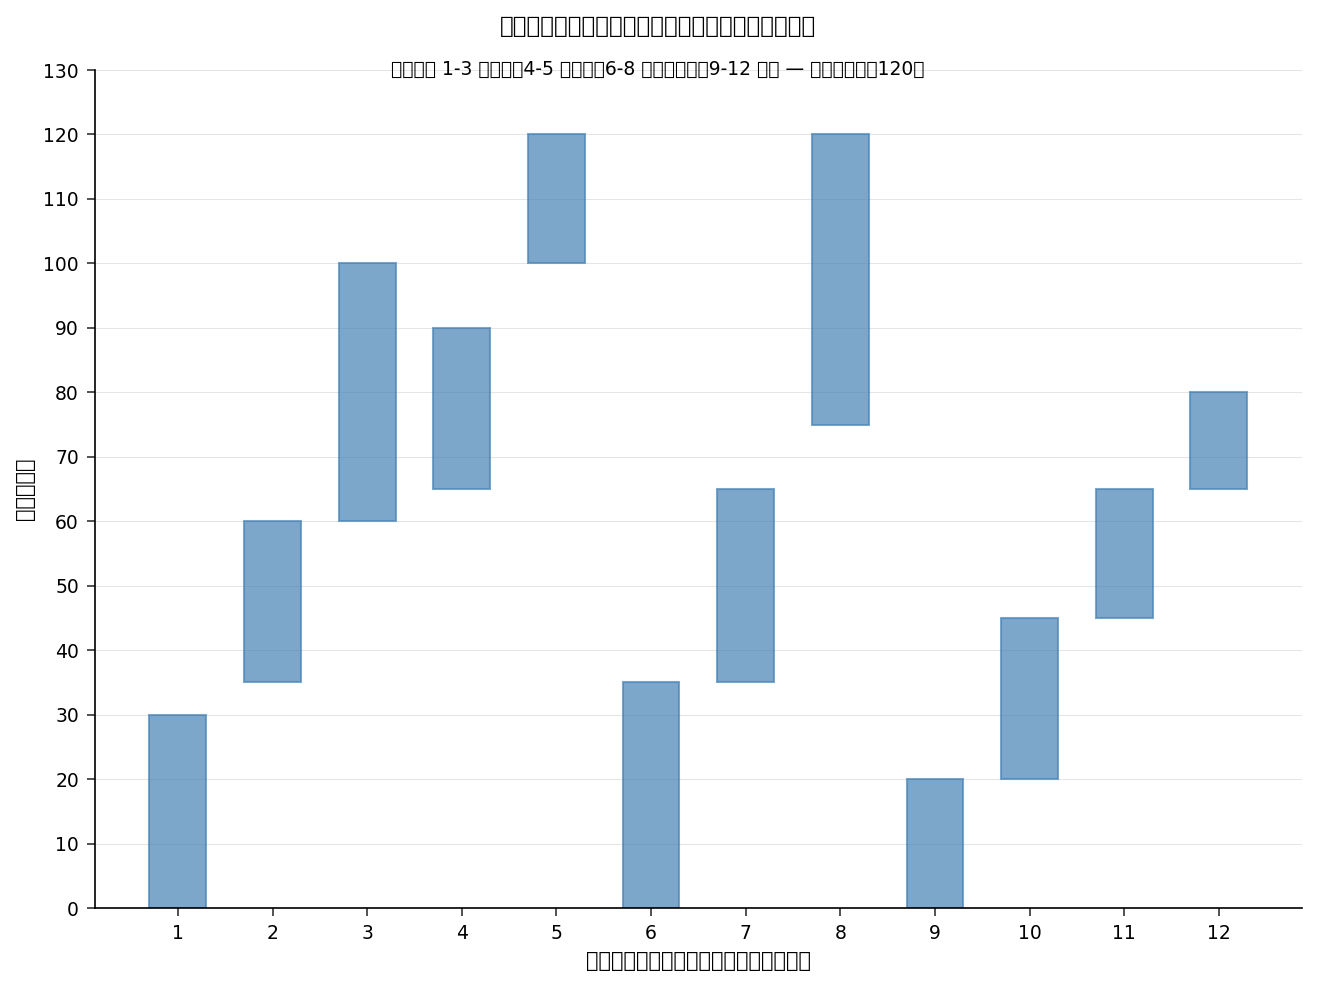

In [4]:
データ ganttdata;
    設定 schedule;
    slot + 1;
実行;

処理 印刷 データ=ganttdata noobs;
    表題 'スロット順スケジュール（下のチャートのスロット順と一致）';
    変数 slot mname jobname START FINISH;
    見出 slot="スロット" mname="機械名" jobname="部品名"
          START="開始(分)" FINISH="終了(分)";
実行;

処理 SGPLOT データ=ganttdata noautolegend;
    表題 '最適ジョブショップスケジュール：各工程の時間枠';
    title2 'スロット 1-3 ドリル、4-5 研削盤、6-8 フライス盤、9-12 鋸盤 — メイクスパン120分';
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS 見出='工程スロット（機械ごとにグループ化）' integer
          VALUES=(1 から 12 基準 1);
    YAXIS 見出='時間（分）' grid VALUES=(0 から 130 基準 10);
実行;
表題;

## 結果の解釈

- **最適性。** MILP ソルバーは `Solution Status = Optimal` を `Objective Value = 120` とともに返しました。したがって **120 分がこのインスタンスに対して証明可能な最短メイクスパン** であり、これより早く終わるスケジュールは存在しません。この証明書こそ、純粋な実行可能性探索に対して数理計画による定式化が与えてくれるものです。

- **スケジュールはすべての制約を守っています。** 機械別の表を読むと、同じ機械上の 2 つの工程が重複することはなく（例：鋸盤 では シャフト 0–20、ブラケット 20–45、ハウジング 45–65、フランジ 65–80）、各部品は技術的順序で進みます（例：ハウジング：ドリル 0–30、次に 鋸盤 45–65、次に フライス盤 75–120）。浮動バーチャートも同じことを示します：各機械のスロット帯内で時間ウィンドウが衝突なく敷き詰められています。

- **スケジュール長を決めるもの。** 2 つの工程がちょうど 120 分で終了します — ブラケット の 研削盤（スロット 5）と ハウジング の フライス盤（スロット 8）。両方がメイクスパンに触れるので、研削盤 と フライス盤 の機械はクリティカルパス上にあります。メイクスパンをさらに削るには、単に順序を組み替えるのではなく、インスタンスそのものを変える（より速い工程、機械の追加、または先行関係の緩和）必要があります。

- **スケールの仕方。** この定式化は自然に拡張します：`machine` の別の値として機械を追加し、`jobshop` の行を増やして部品を追加し、または `s[o]` を上下限で縛り納期制約を加えてリリース日と納期をモデル化します。機械が同時に複数のジョブを実行できるようにする（能力 >1）場合は、ペアごとの選言をカムラティブ資源制約に置き換えます。同じ OPTMODEL MILP が、ソルバーを変えることなく、より豊かな現場ルールを扱えます。